In [2]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mis_dro.plot import flexible_figure

In [8]:
experiment_dir = Path("/dcs/large/u1508153/misdro/compare_solve")
assert experiment_dir.exists()
results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])
with open(experiment_dir / "experiment.json", "r") as json_file:
    experiment = json.load(json_file)

# check the number of train/test observations is the same:
assert len(results_df["num_observations"].unique()) == 1
assert len(results_df["num_test_observations"].unique()) == 1

results_df = results_df.loc[results_df["posterior"] == "normal_gamma"]

In [9]:
gb = results_df.groupby(by=["algorithm", "dgp", "epsilon", "posterior"])
agg_df = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
    "posterior_time": ["mean"],
    "setup_time": ["mean"],
    "solve_time": ["mean"],
    "solution": ["mean", "var"],
})
agg_df

mean_cost             \
                                                             mean        var   
algorithm        dgp              epsilon posterior                            
bdro_grid_search truncated_normal 0.001   normal_gamma  32.121660  16.838443   
                                  0.010   normal_gamma  32.223308  16.955209   
                                  0.100   normal_gamma  32.705245  18.219628   
                                  1.000   normal_gamma  35.362477  29.605642   
                                  10.000  normal_gamma  40.087458  52.890994   
                                  100.000 normal_gamma  40.087458  52.890994   
normal_gamma_dro truncated_normal 0.001   normal_gamma  32.498116  19.020503   
                                  0.010   normal_gamma  33.240692  20.494198   
                                  0.100   normal_gamma  36.471710  43.684206   
                                  1.000   normal_gamma  36.221596  43.587779   
                                  10.000  normal_gamma  36.221596  43.587778   
                                  100.000 normal_gamma  36.221597  43.587774   

                                                          var_cost  \
                                                              mean   
algorithm        dgp              epsilon posterior                  
bdro_grid_search truncated_normal 0.001   normal_gamma  610.820139   
                                  0.010   normal_gamma  591.964915   
                                  0.100   normal_gamma  542.571275   
                                  1.000   normal_gamma  457.775431   
                                  10.000  normal_gamma  432.180646   
                                  100.000 normal_gamma  432.180646   
normal_gamma_dro truncated_normal 0.001   normal_gamma  599.912077   
                                  0.010   normal_gamma  532.760407   
                                  0.100   normal_gamma  472.787661   
                                  1.000   normal_gamma  483.106412   
                                  10.000  normal_gamma  483.106398   
                                  100.000 normal_gamma  483.106361   

                                                       posterior_time  \
                                                                 mean   
algorithm        dgp              epsilon posterior                     
bdro_grid_search truncated_normal 0.001   normal_gamma       0.000565   
                                  0.010   normal_gamma       0.000576   
                                  0.100   normal_gamma       0.000621   
                                  1.000   normal_gamma       0.000615   
                                  10.000  normal_gamma       0.000580   
                                  100.000 normal_gamma       0.000587   
normal_gamma_dro truncated_normal 0.001   normal_gamma       0.000062   
                                  0.010   normal_gamma       0.000059   
                                  0.100   normal_gamma       0.000068   
                                  1.000   normal_gamma       0.000067   
                                  10.000  normal_gamma       0.000068   
                                  100.000 normal_gamma       0.000063   

                                                       setup_time  solve_time  \
                                                             mean        mean   
algorithm        dgp              epsilon posterior                             
bdro_grid_search truncated_normal 0.001   normal_gamma        0.0  163.522348   
                                  0.010   normal_gamma        0.0   82.682829   
                                  0.100   normal_gamma        0.0   87.881817   
                                  1.000   normal_gamma        0.0   95.589307   
                                  10.000  normal_gamma        0.0   36.151952   
                                  100.000 normal_gamma      

## Plot mean-variance trade-off

For each DGP, we plot the out-of-sample mean $\hat{\mu}_M(\epsilon)$ and variance $\hat{\sigma}_M(\epsilon)$ of Bayesian DRO with different posteriors.

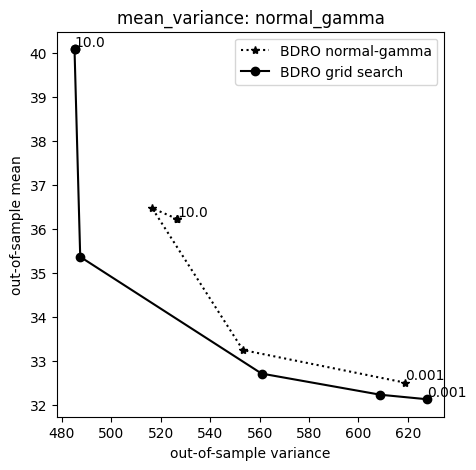

In [11]:
fig, axes = flexible_figure(agg_df, "mean_variance", gb_col="posterior", ncols=1)
fig.show()

## Solve time

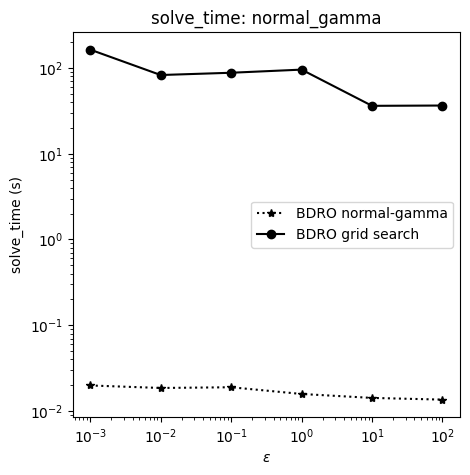

In [13]:
fig, axes = flexible_figure(agg_df, "solve_time", gb_col="posterior", sharex=True, sharey=True, ncols=1)
fig.show()